Analyzing Credit Card Approval Data

STATUS - 
0: 1-29 days past due 
1: 30-59 days past due 
2: 60-89 days overdue 
3: 90-119 days overdue 
4: 120-149 days overdue 
5: Overdue or bad debts, write-offs for more than 150 days 
C: paid off that month 
X: No loan for the month

In [53]:
##Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Perceptron
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import StackingClassifier

from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict, KFold


from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")


In [54]:
##Load the Data
app = pd.read_csv('/Users/obo/Documents/Data Science Course/Mini Project 2/application_record.csv')
credit = pd.read_csv('/Users/obo/Documents/Data Science Course/Mini Project 2/credit_record.csv')

app.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [55]:
credit.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [56]:
credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


In [57]:
app.shape

(438557, 18)

In [58]:
credit.shape

(1048575, 3)

In [59]:
app.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

In [60]:
app.corr(numeric_only=True)

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS
ID,1.000000,-0.005178,0.011179,-0.004994,-0.002467,NaN,-0.023319,-0.018992,0.032875,-0.001862
CNT_CHILDREN,-0.005178,1.000000,0.019177,0.349088,-0.241535,NaN,0.038418,-0.038266,0.028457,0.884781
AMT_INCOME_TOTAL,0.011179,0.019177,1.000000,0.053775,-0.141291,NaN,-0.033635,0.004444,0.112139,0.011454
DAYS_BIRTH,-0.004994,0.349088,0.053775,1.000000,-0.617908,NaN,0.171829,-0.037984,0.096752,0.306179
DAYS_EMPLOYED,-0.002467,-0.241535,-0.141291,-0.617908,1.000000,NaN,-0.232208,0.004868,-0.074372,-0.234373
FLAG_MOBIL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_WORK_PHONE,-0.023319,0.038418,-0.033635,0.171829,-0.232208,NaN,1.000000,0.290066,-0.060915,0.049777
FLAG_PHONE,-0.018992,-0.038266,0.004444,-0.037984,0.004868,NaN,0.290066,1.000000,-0.001170,-0.024213
FLAG_EMAIL,0.032875,0.028457,0.112139,0.096752,-0.074372,NaN,-0.060915,-0.001170,1.000000,0.022054
CNT_FAM_MEMBERS,-0.001862,0.884781,0.011454,0.306179,-0.234373,NaN,0.049777,-0.024213,0.022054,1.000000


In [61]:
app.isnull().sum()

ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        134203
CNT_FAM_MEMBERS             0
dtype: int64

In [62]:
credit.isnull().sum()

ID                0
MONTHS_BALANCE    0
STATUS            0
dtype: int64

In [63]:
app = app.drop('OCCUPATION_TYPE', axis=1)
app.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,1.0


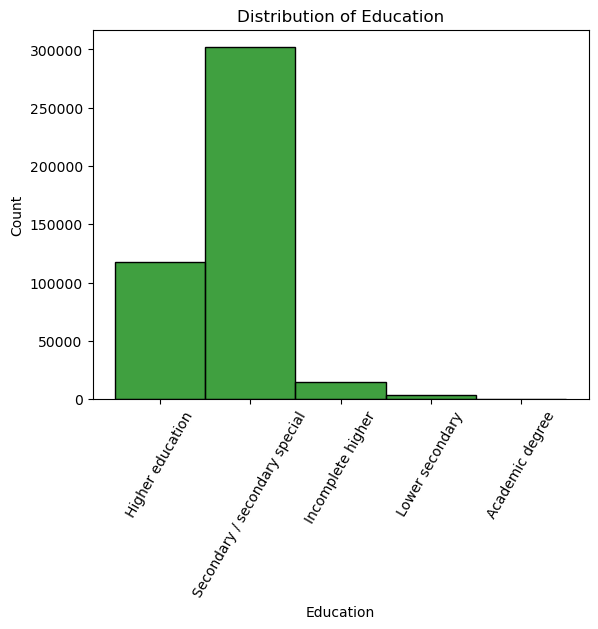

In [64]:
plt.title('Distribution of Education')
plt.xlabel('Education')
plt.ylabel('Count')
plt.xticks(rotation=60)
sns.histplot(data=app, x='NAME_EDUCATION_TYPE', color= 'green')
plt.show()

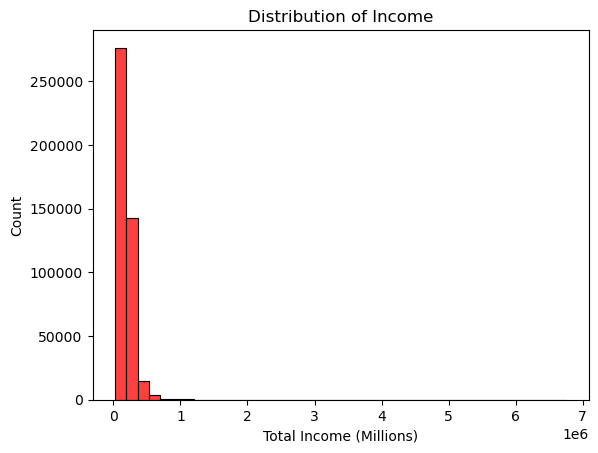

In [65]:
plt.title('Distribution of Income')
plt.xlabel('Total Income (Millions)')
plt.ylabel('Count')
sns.histplot(data=app, x='AMT_INCOME_TOTAL', color='red', bins=40)
plt.show()

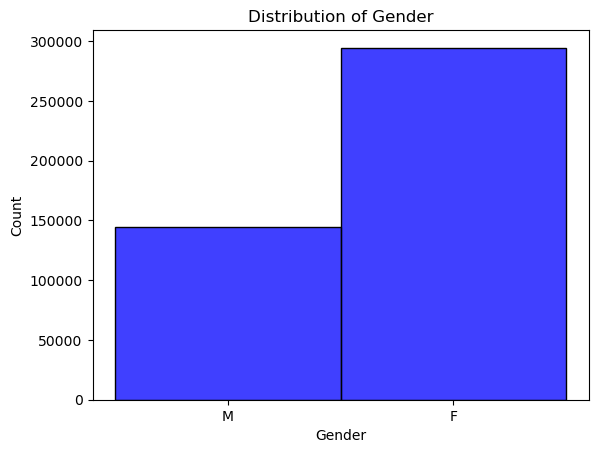

In [66]:
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
sns.histplot(data=app, x='CODE_GENDER', color='blue', bins=10)
plt.show()

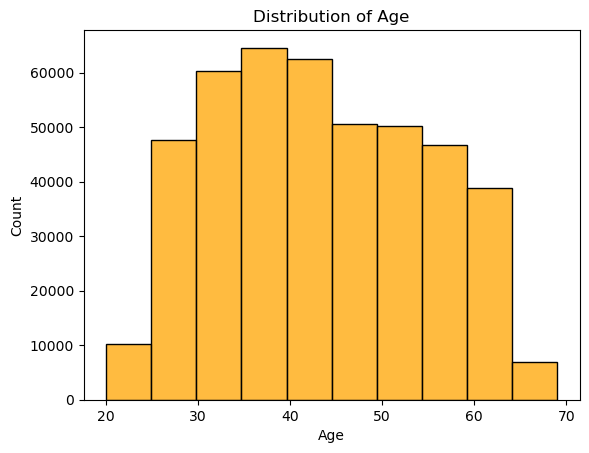

In [67]:
app['AGE'] = app['DAYS_BIRTH'] // -365
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
sns.histplot(data=app, x='AGE', color='orange', bins=10)
plt.show()

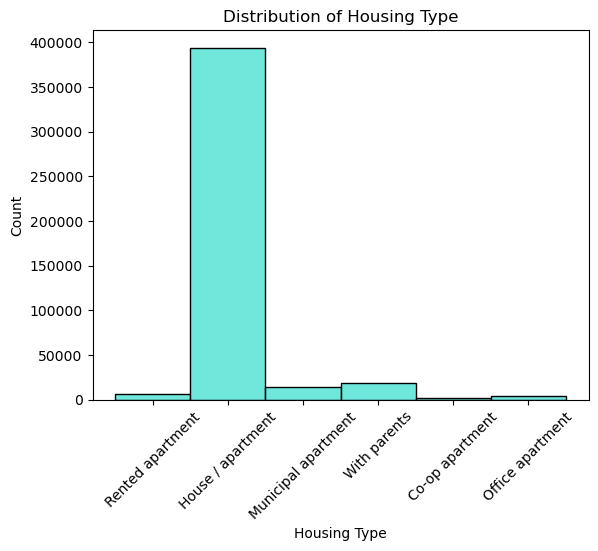

In [68]:
plt.title('Distribution of Housing Type')
plt.xlabel('Housing Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
sns.histplot(data=app, x='NAME_HOUSING_TYPE', color='turquoise', bins=10)
plt.show()

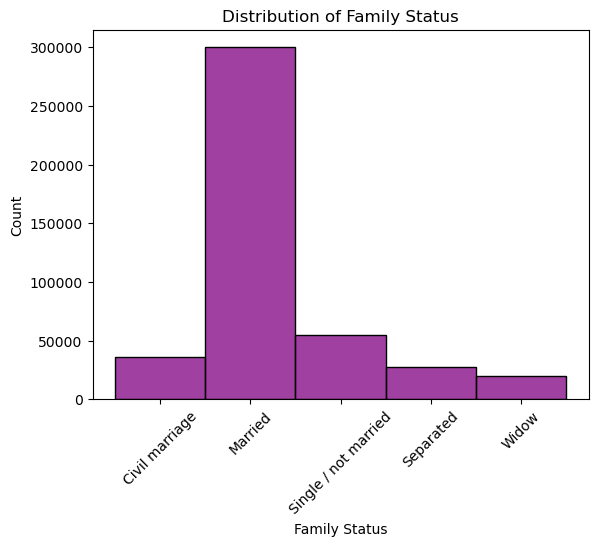

In [69]:
plt.title('Distribution of Family Status')
plt.xlabel('Family Status')
plt.ylabel('Count')
sns.histplot(data=app, x='NAME_FAMILY_STATUS', color='purple', bins=10)
plt.xticks(rotation=45)
plt.show()

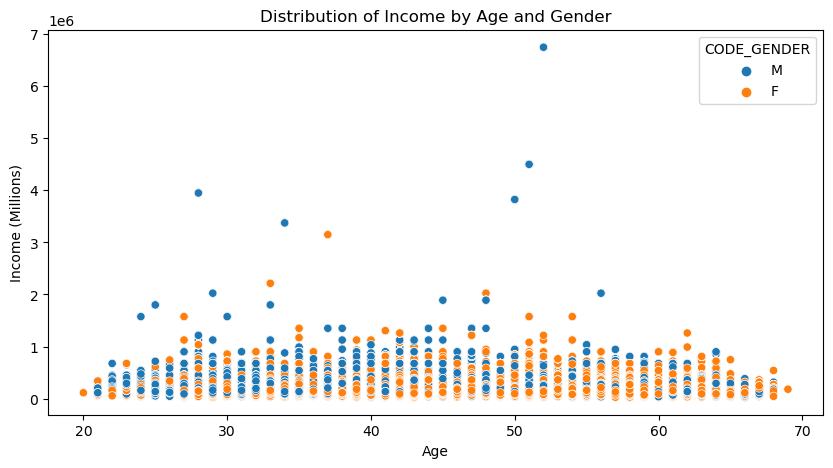

In [70]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=app, x='AGE', y='AMT_INCOME_TOTAL', hue='CODE_GENDER')
plt.title('Distribution of Income by Age and Gender')
plt.xlabel('Age')
plt.ylabel('Income (Millions)')
plt.show()

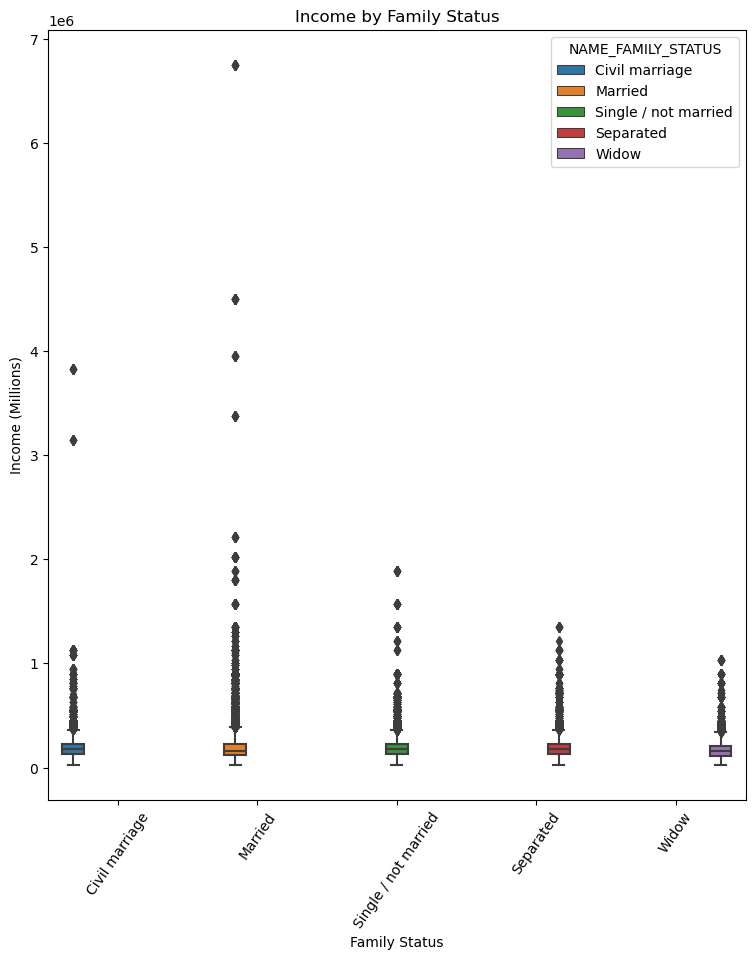

In [71]:
plt.figure(figsize=(9, 10))
sns.boxplot(data=app, x='NAME_FAMILY_STATUS', y='AMT_INCOME_TOTAL', hue='NAME_FAMILY_STATUS')
plt.title('Income by Family Status')
plt.xlabel('Family Status')
plt.ylabel('Income (Millions)')
plt.xticks(rotation=55)
plt.show()

In [72]:
final_df = pd.merge(app, credit, on='ID')
final_df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,AGE,MONTHS_BALANCE,STATUS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,2.0,32,0,C
1,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,2.0,32,-1,C
2,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,2.0,32,-2,C
3,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,2.0,32,-3,C
4,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,2.0,32,-4,C


In [107]:
final_df.corr(numeric_only=True)

,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,AGE,...,NAME_EDUCATION_TYPE_Secondary / secondary special,NAME_FAMILY_STATUS_Married,NAME_FAMILY_STATUS_Separated,NAME_FAMILY_STATUS_Single / not married,NAME_FAMILY_STATUS_Widow,NAME_HOUSING_TYPE_House / apartment,NAME_HOUSING_TYPE_Municipal apartment,NAME_HOUSING_TYPE_Office apartment,NAME_HOUSING_TYPE_Rented apartment,NAME_HOUSING_TYPE_With parents
CNT_CHILDREN,1.000000,0.039304,0.356177,-0.228945,NaN,0.042226,-0.018882,0.015726,0.892079,-0.356017,...,-0.049112,0.145374,-0.016431,-0.128647,-0.095514,-0.028194,-0.002549,0.020883,-0.003143,0.036139
AMT_INCOME_TOTAL,0.039304,1.000000,0.081231,-0.180674,NaN,-0.021229,0.018687,0.085776,0.031379,-0.081093,...,-0.217333,0.011225,0.014448,0.014252,-0.037165,-0.001756,-0.018534,0.027719,0.023273,-0.013334
DAYS_BIRTH,0.356177,0.081231,1.000000,-0.608856,NaN,0.180658,-0.026717,0.100945,0.327750,-0.999674,...,-0.177942,0.034873,-0.058646,0.076144,-0.221441,-0.162678,-0.000809,0.014122,0.064528,0.188780
DAYS_EMPLOYED,-0.228945,-0.180674,-0.608856,1.000000,NaN,-0.243677,-0.013817,-0.082474,-0.227645,0.608849,...,0.109677,-0.059985,0.001020,-0.010189,0.200086,0.093856,-0.010980,-0.012060,-0.033625,-0.094626
FLAG_MOBIL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_WORK_PHONE,0.042226,-0.021229,0.180658,-0.243677,NaN,1.000000,0.312552,-0.037991,0.060183,-0.181275,...,-0.028857,0.042512,-0.008329,-0.030057,-0.056525,-0.023996,-0.013308,-0.009754,0.015026,0.033370
FLAG_PHONE,-0.018882,0.018687,-0.026717,-0.013817,NaN,0.312552,1.000000,0.011901,-0.007824,0.026586,...,-0.046940,0.027001,0.013529,-0.028787,-0.003148,0.015427,0.000868,-0.018516,-0.024276,0.001058
FLAG_EMAIL,0.015726,0.085776,0.100945,-0.082474,NaN,-0.037991,0.011901,1.000000,0.012540,-0.100706,...,-0.089635,-0.008349,-0.012634,0.017195,-0.012654,0.000142,-0.001243,-0.010437,0.024107,-0.002469
CNT_FAM_MEMBERS,0.892079,0.031379,0.327750,-0.227645,NaN,0.060183,-0.007824,0.012540,1.000000,-0.327615,...,-0.038570,0.489951,-0.227383,-0.422424,-0.254303,-0.006558,-0.011511,0.014752,-0.018456,0.023940
AGE,-0.356017,-0.081093,-0.999674,0.608849,NaN,-0.181275,0.026586,-0.100706,-0.327615,1.000000,...,0.178238,-0.034802,0.059196,-0.076076,0.220690,0.161891,0.001384,-0.014021,-0.064873,-0.187914


In [73]:
def client_label(status):
    if status in ['2', '3', '4', '5']:
        return 'bad'
    else:
        return 'good'

In [74]:
final_df['client_status'] = final_df['STATUS'].apply(client_label)
final_df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,AGE,MONTHS_BALANCE,STATUS,client_status
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,2.0,32,0,C,good
1,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,2.0,32,-1,C,good
2,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,2.0,32,-2,C,good
3,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,2.0,32,-3,C,good
4,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,2.0,32,-4,C,good


In [75]:
le = LabelEncoder()
scale = StandardScaler()

In [76]:
final_df['client_status'] = le.fit_transform(final_df['client_status'])
final_df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,AGE,MONTHS_BALANCE,STATUS,client_status
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,2.0,32,0,C,1
1,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,2.0,32,-1,C,1
2,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,2.0,32,-2,C,1
3,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,2.0,32,-3,C,1
4,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,2.0,32,-4,C,1


In [77]:
final_df.drop(columns=['ID', 'MONTHS_BALANCE', 'STATUS'], inplace=True)

In [78]:
final_df.head()

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,AGE,client_status
0,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,2.0,32,1
1,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,2.0,32,1
2,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,2.0,32,1
3,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,2.0,32,1
4,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,2.0,32,1


In [79]:
final_df.dtypes

CODE_GENDER             object
FLAG_OWN_CAR            object
FLAG_OWN_REALTY         object
CNT_CHILDREN             int64
AMT_INCOME_TOTAL       float64
NAME_INCOME_TYPE        object
NAME_EDUCATION_TYPE     object
NAME_FAMILY_STATUS      object
NAME_HOUSING_TYPE       object
DAYS_BIRTH               int64
DAYS_EMPLOYED            int64
FLAG_MOBIL               int64
FLAG_WORK_PHONE          int64
FLAG_PHONE               int64
FLAG_EMAIL               int64
CNT_FAM_MEMBERS        float64
AGE                      int64
client_status            int64
dtype: object

In [80]:
categorical_cols = final_df.select_dtypes(include=['object']).columns
final_df = pd.get_dummies(final_df, columns=categorical_cols, drop_first=True)
final_df.head()

,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,AGE,...,NAME_EDUCATION_TYPE_Secondary / secondary special,NAME_FAMILY_STATUS_Married,NAME_FAMILY_STATUS_Separated,NAME_FAMILY_STATUS_Single / not married,NAME_FAMILY_STATUS_Widow,NAME_HOUSING_TYPE_House / apartment,NAME_HOUSING_TYPE_Municipal apartment,NAME_HOUSING_TYPE_Office apartment,NAME_HOUSING_TYPE_Rented apartment,NAME_HOUSING_TYPE_With parents
0,0,427500.0,-12005,-4542,1,1,0,0,2.0,32,...,False,False,False,False,False,False,False,False,True,False
1,0,427500.0,-12005,-4542,1,1,0,0,2.0,32,...,False,False,False,False,False,False,False,False,True,False
2,0,427500.0,-12005,-4542,1,1,0,0,2.0,32,...,False,False,False,False,False,False,False,False,True,False
3,0,427500.0,-12005,-4542,1,1,0,0,2.0,32,...,False,False,False,False,False,False,False,False,True,False
4,0,427500.0,-12005,-4542,1,1,0,0,2.0,32,...,False,False,False,False,False,False,False,False,True,False


In [81]:
final_df.isnull().sum()

CNT_CHILDREN                                         0
AMT_INCOME_TOTAL                                     0
DAYS_BIRTH                                           0
DAYS_EMPLOYED                                        0
FLAG_MOBIL                                           0
FLAG_WORK_PHONE                                      0
FLAG_PHONE                                           0
FLAG_EMAIL                                           0
CNT_FAM_MEMBERS                                      0
AGE                                                  0
client_status                                        0
CODE_GENDER_M                                        0
FLAG_OWN_CAR_Y                                       0
FLAG_OWN_REALTY_Y                                    0
NAME_INCOME_TYPE_Pensioner                           0
NAME_INCOME_TYPE_State servant                       0
NAME_INCOME_TYPE_Student                             0
NAME_INCOME_TYPE_Working                             0
NAME_EDUCA

In [82]:
final_df.fillna(final_df.mean(), inplace=True)

In [83]:
X = final_df.drop(columns=['client_status'])
y = final_df['client_status']

In [84]:
smote = SMOTE()
X_resampled, Y_resampled = smote.fit_resample(X, y)

In [85]:
X_resampled = scale.fit_transform(X_resampled)

In [86]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, Y_resampled, test_size=0.2, random_state=123)

In [87]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
y_pred_lr = logreg.predict(X_test)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print('Logistic Regression Accuracy: ', accuracy_lr)

Logistic Regression Accuracy:  0.6432256295268668


In [88]:
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=123)

scores = cross_val_score(logreg, X_train, y_train, cv=kf, scoring='accuracy')

print(f"Accuracy for each fold: {scores}")
print(f"Average accuracy across all folds: {scores.mean():.4f}")

Accuracy for each fold: [0.64073414 0.64178268 0.64362165 0.64254892 0.64299109]
Average accuracy across all folds: 0.6423


In [89]:
base_learner = LogisticRegression()

adaboost = AdaBoostClassifier(base_estimator=base_learner, n_estimators=200, learning_rate=1.0, random_state=123)

adaboost.fit(X_train, y_train)

y_pred_lrboost = adaboost.predict(X_test)

accuracy_lrboost = accuracy_score(y_test, y_pred_lrboost)
print('Logistic Regression Boosted Accuracy: ', accuracy_lrboost)

Logistic Regression Boosted Accuracy:  0.6368021164362568


In [90]:
base_learners = [
    ('decision_tree', DecisionTreeClassifier(max_depth=3)),
    ('random_forest', RandomForestClassifier(n_estimators=50, random_state=123)),
    ('perceptron', Perceptron(random_state=123)),
]

# Define the meta-learner (final model that combines predictions of base learners)
meta_learner = LogisticRegression()

# Define the stacking classifier
stacking_model = StackingClassifier(estimators=base_learners, final_estimator=meta_learner, cv=5)

# Train the stacking model
stacking_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_stack = stacking_model.predict(X_test)

# Evaluate the stacking model
accuracy_stack = accuracy_score(y_test, y_pred_stack)

print('Stacking Classifier Accuracy: ', accuracy_stack)

Stacking Classifier Accuracy:  0.981226307044571


In [91]:
class_rep = classification_report(y_test, y_pred_stack)
print(class_rep)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98    155135
           1       0.99      0.97      0.98    154820

    accuracy                           0.98    309955
   macro avg       0.98      0.98      0.98    309955
weighted avg       0.98      0.98      0.98    309955



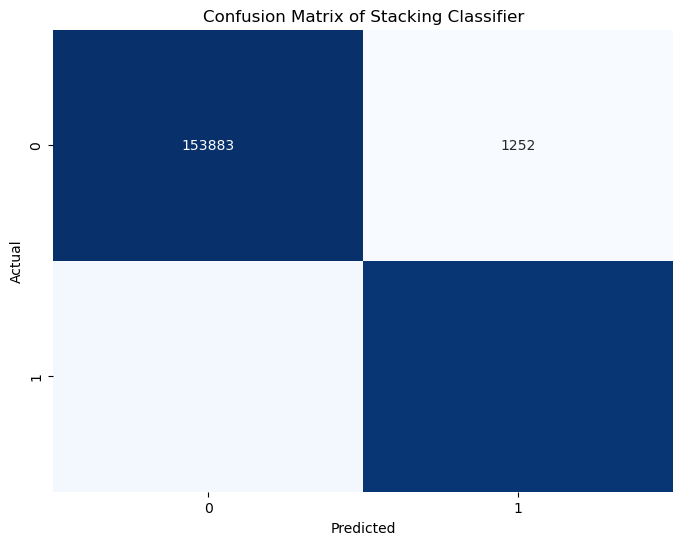

In [92]:
conf_matrix = confusion_matrix(y_test, y_pred_stack)

plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix of Stacking Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [93]:
y_pred_proba_stack = stacking_model.predict_proba(X_test)[:, 1]
fpr, tpr, threshold = roc_curve(y_test, y_pred_proba_stack)
roc_auc_stack = auc(fpr, tpr)

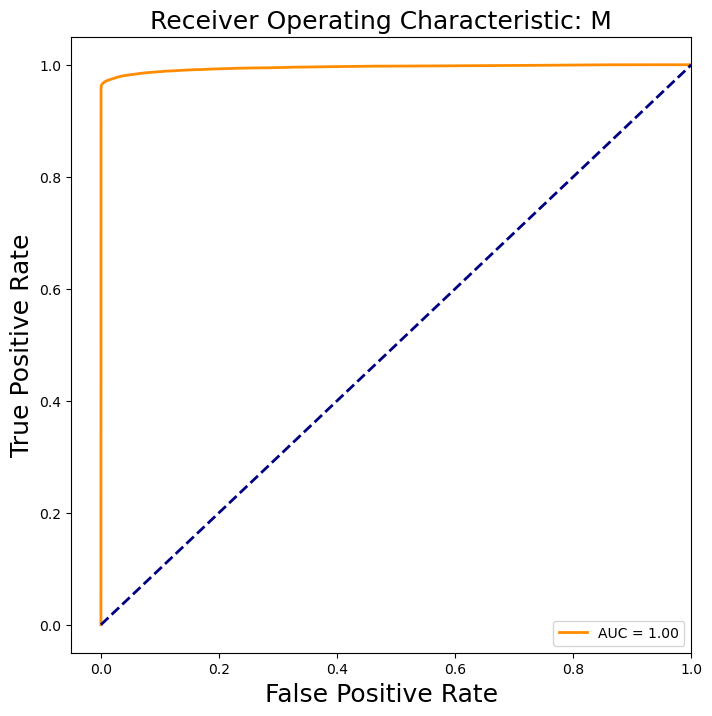

In [94]:
plt.figure(figsize=[8,8])
lw = 2
plt.plot(fpr, tpr, label='AUC = %0.2f' % roc_auc_stack, color='darkorange', lw=lw)
plt.plot([0, 1], [0, 1], color = 'navy', lw = lw, linestyle = '--')
plt.xlim([-0.05, 1.0])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate', fontsize=18)
plt.ylabel('True Positive Rate', fontsize=18)
plt.title('Receiver Operating Characteristic: M', fontsize=18)
plt.legend(loc="lower right")
plt.show()

In [95]:
y_pred_dt = dt.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print('Decision Tree Accuracy: ', accuracy_dt)

Decision Tree Accuracy:  0.98179090513139


In [96]:
class_rep2 = classification_report(y_test, y_pred_dt)
print(class_rep2)

              precision    recall  f1-score   support

           0       0.97      1.00      0.98    155135
           1       1.00      0.97      0.98    154820

    accuracy                           0.98    309955
   macro avg       0.98      0.98      0.98    309955
weighted avg       0.98      0.98      0.98    309955



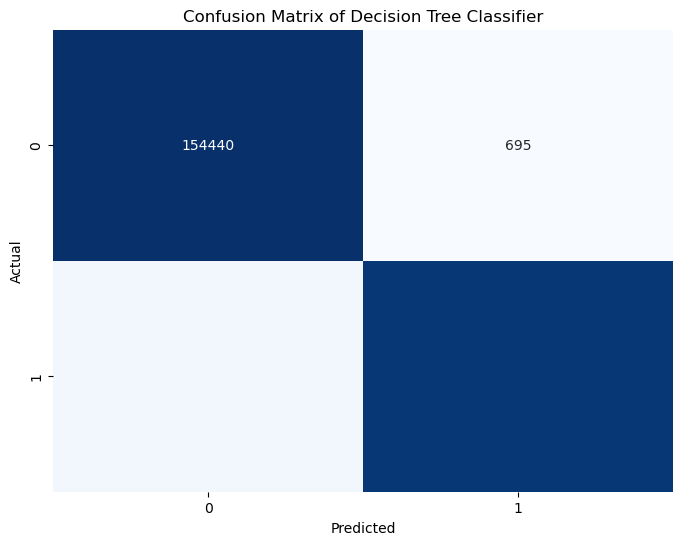

In [97]:
conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix_dt, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix of Decision Tree Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [99]:
y_pred_proba_dt = dt.predict_proba(X_test)[:, 1]
fpr2, tpr2, threshold = roc_curve(y_test, y_pred_proba_dt)
roc_auc_dt = auc(fpr2, tpr2)

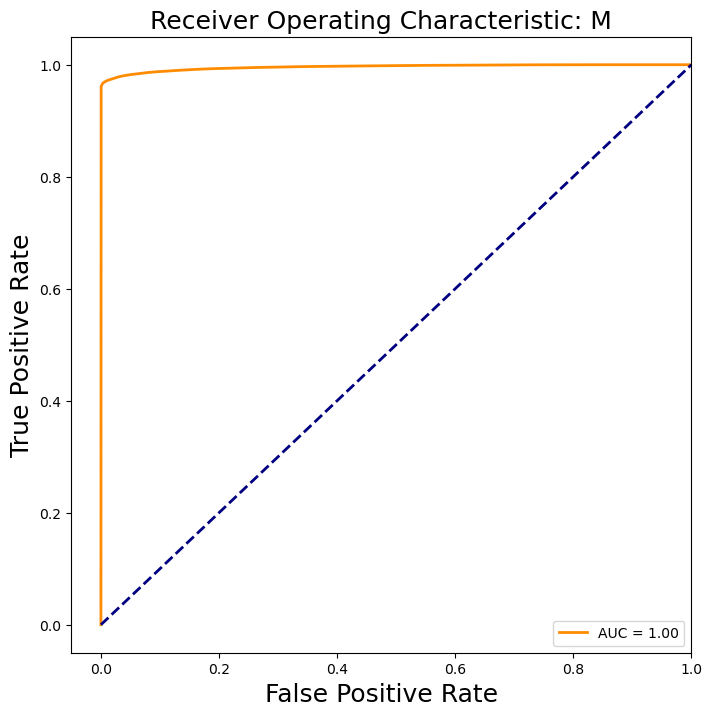

In [100]:
plt.figure(figsize=[8,8])
lw = 2
plt.plot(fpr2, tpr2, label='AUC = %0.2f' % roc_auc_dt, color='darkorange', lw=lw)
plt.plot([0, 1], [0, 1], color = 'navy', lw = lw, linestyle = '--')
plt.xlim([-0.05, 1.0])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate', fontsize=18)
plt.ylabel('True Positive Rate', fontsize=18)
plt.title('Receiver Operating Characteristic: M', fontsize=18)
plt.legend(loc="lower right")
plt.show()

In [101]:
y_pred_rf = rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print('Random Forest Accuracy: ', accuracy_rf)

Random Forest Accuracy:  0.9818392992531174


In [102]:
class_rep3 = classification_report(y_test, y_pred_rf)
print(class_rep3)

              precision    recall  f1-score   support

           0       0.97      1.00      0.98    155135
           1       1.00      0.97      0.98    154820

    accuracy                           0.98    309955
   macro avg       0.98      0.98      0.98    309955
weighted avg       0.98      0.98      0.98    309955



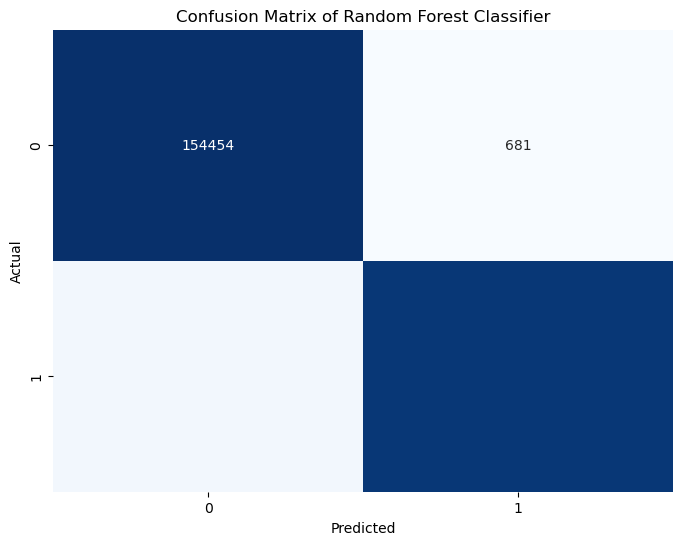

In [103]:
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix of Random Forest Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [104]:
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]
fpr3, tpr3, threshold3 = roc_curve(y_test, y_pred_proba_rf)
roc_auc_rf = auc(fpr3, tpr3)

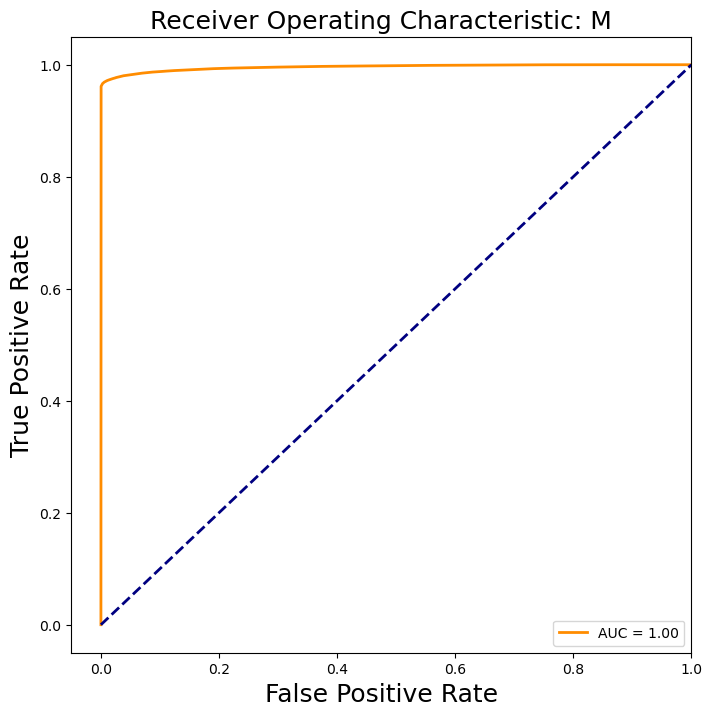

In [105]:
plt.figure(figsize=[8,8])
lw = 2
plt.plot(fpr3, tpr3, label='AUC = %0.2f' % roc_auc_rf, color='darkorange', lw=lw)
plt.plot([0, 1], [0, 1], color = 'navy', lw = lw, linestyle = '--')
plt.xlim([-0.05, 1.0])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate', fontsize=18)
plt.ylabel('True Positive Rate', fontsize=18)
plt.title('Receiver Operating Characteristic: M', fontsize=18)
plt.legend(loc="lower right")
plt.show()